### People Analytics Case Study

# Employee Attrition Analysis

# Scenario

Kansora Medical is a fictional medical device manufacturing company based in Osaka, employing approximately 5,000 people across functions including Research & Development, Sales and Manufacturing.

Like many employers in Japan, Kansora Medical operates in a tight labour market and is finding it increasingly difficult to attract and retain skilled employees. It is especially concerned with retaining its most high performing employees. "High performers" are defined as those employees with the performance rating "Excellent" or "Outstanding", who together account for the top 30% of the total employee population. Management has asked Kansora Medical's People Analytics team to identify the employee and workplace factors most strongly associated with high performers leaving the organisation.

This analysis uses IBM’s synthetic HR employee attrition dataset. For the purposes of this case study, the 1,470 employee records are treated as employees active at the beginning of a 12-month observation period. `Attrition = Yes` indicates that an employee left the organisation during that period, while `Attrition = No` indicates that the employee remained employed.

The analysis aims to understand:

- the overall characteristics of the workforce and the distribution of employee attrition (Section 1)
- how attrition varies across demographic and background characteristics (Section 2)
- how job characteristics, working conditions and career experience are associated with attrition (Section 3)
- how compensation, satisfaction and engagement-related factors are associated with attrition (Section 4)
- which factors remain associated with attrition when considered simultaneously using multivariate analysis (Section 5)
- how effectively attrition can be predicted and whether decision-tree modelling can identify meaningful employee segments (Section 6)
- what practical insights the findings may provide for HR and management, together with the limitations of the analysis (Section 7)

# Section 1: Workforce characteristics and employee attrition distribution

As a first step, the analysis examines the overall structure and quality of the employee dataset before investigating the factors associated with attrition.

This section focuses on checking data completeness and variable types, reviewing key workforce characteristics and distributions, and establishing the overall proportion of employees recorded as `Attrition = Yes` and `Attrition = No`. These initial checks provide the foundation for the more detailed bivariate and multivariate analyses in later sections.

## 1.1 Load and explore the data

In [49]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# For readability: Show two decimal places for all floating-point numbers
pd.set_option('display.precision', 2)

In [50]:
# Load the CSV file(s) as employee_data.
employee_data = pd.read_csv ("ibm_hr_analytics_employee_attrition_and_performance_revised.csv")

# View the DataFrame.
employee_data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,...,Excellent,Very High,1,6,3,Better,2,2,2,2


In [51]:
# Explore the data.
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   object
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   object
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   object
 12  JobLevel                  1470 non-null   object
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [52]:
# Check for duplicates.
employee_data.duplicated().sum()

np.int64(0)

### Initial data quality observations

- The dataset contains **1,470 rows and 31 columns**.

- All 31 variables contain **1,470 non-null values**, indicating that there are no missing values in the dataset.

- The data types appear appropriate for the current analysis: **15 variables are numeric (`int64`)** and **16 are categorical (`object`)**.

- No obvious data type corrections are required at this stage, although the categorical variables will be reviewed further as part of the exploratory analysis.

- A duplicate check identified **0 duplicate records**, indicating that each row in the dataset is unique.

In [53]:
# Basic descriptive statistics.
employee_data.describe()

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,65.89,6502.93,14313.10,2.69,15.21,0.79,11.28,2.80,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,20.33,4707.96,7117.79,2.50,3.66,0.85,7.78,1.29,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,30.00,1009.00,2094.00,0.00,11.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,48.00,2911.00,8047.00,1.00,12.00,0.00,6.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,66.00,4919.00,14235.50,2.00,14.00,1.00,10.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,83.75,8379.00,20461.50,4.00,18.00,1.00,15.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,100.00,19999.00,26999.00,9.00,25.00,3.00,40.00,6.00,40.00,18.00,15.00,17.00


In [54]:
# Establish the number of employees recorded as Attrition = Yes and Attrition = No
employee_data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [55]:
# Establish the proportion (percentage) of employees recorded as Attrition = Yes and Attrition = No
attrition_pct = employee_data['Attrition'].value_counts(normalize=True) * 100
attrition_pct.round(1)

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

### Initial observations from descriptive statistics

- The dataset contains **1,470 employee records**, with no missing values across the variables reviewed.
- Employees vary substantially in **age, income, tenure, and overall work experience**, providing useful variation for subsequent analysis.
- Several variables appear **right-skewed**, particularly `MonthlyIncome`, `YearsAtCompany`, and `YearsSinceLastPromotion`, with relatively small numbers of employees at much higher values. These patterns may reflect differences in seniority, career stage, or progression and will be explored further in relation to attrition.
- Attrition is relatively uncommon: approximately **16% of employees are recorded as `Attrition = Yes`**, compared with about **84% as `Attrition = No`**. This class imbalance is important when interpreting later comparisons and predictive modelling.
- The business meaning of `DailyRate`, `HourlyRate`, and `MonthlyRate` is unclear, so these variables will not be treated as substantive predictors without further justification.

## 1.2 Reorder columns

To support a more structured analysis, the dataset columns are reordered into thematic groups such as demographics, job characteristics, compensation, experience and tenure, and engagement-related factors.

In [56]:
column_order = [
    # Outcome
    "Attrition",

    # Demographics / background
    "Age",
    "Gender",
    "MaritalStatus",
    "Education",
    "EducationField",

    # Job characteristics
    "Department",
    "JobRole",
    "JobLevel",
    "BusinessTravel",
    "OverTime",
    "DistanceFromHome",

    # Compensation / rewards
    "MonthlyIncome",
    "DailyRate",
    "HourlyRate",
    "MonthlyRate",
    "PercentSalaryHike",
    "StockOptionLevel",

    # Experience / tenure
    "TotalWorkingYears",
    "NumCompaniesWorked",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear",

    # Engagement / satisfaction
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance",
    "PerformanceRating"
]

employee_data = employee_data[column_order]

In [57]:
# Check the reordered DataFrame.
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Attrition                 1470 non-null   object
 1   Age                       1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   MaritalStatus             1470 non-null   object
 4   Education                 1470 non-null   object
 5   EducationField            1470 non-null   object
 6   Department                1470 non-null   object
 7   JobRole                   1470 non-null   object
 8   JobLevel                  1470 non-null   object
 9   BusinessTravel            1470 non-null   object
 10  OverTime                  1470 non-null   object
 11  DistanceFromHome          1470 non-null   int64 
 12  MonthlyIncome             1470 non-null   int64 
 13  DailyRate                 1470 non-null   int64 
 14  HourlyRate              

# Section 2: Attrition by demographic and background characteristics

Having established the overall structure and quality of the dataset, the next step is to examine how attrition varies across key demographic and background variables.

This section considers age, gender, marital status, education, and education field. Attrition rates are compared across relevant groups using summary tables to identify notable differences or patterns.

The analysis at this stage is descriptive rather than causal. Any observed differences may highlight areas for further investigation, but they should not be interpreted as evidence that a particular characteristic directly causes employee attrition.

In [58]:
# Define a function to summarise group size and attrition rate
def attrition_summary(variable):
    return (
        employee_data.groupby(variable, observed=False)
        .agg(
            EmployeeCount=("Attrition", "size"),
            AttritionRate=("Attrition", lambda x: (x == "Yes").mean() * 100)
        )
        .round(2)
    )

In [59]:
# Create grouped variables for Section 2

# Age
age_bins = [17, 29, 39, 49, 60]
age_labels = [
    "18–29",
    "30–39",
    "40–49",
    "50–60"
]

employee_data["AgeGroup"] = pd.cut(
    employee_data["Age"],
    bins=age_bins,
    labels=age_labels
)

# Set logical order for education categories
education_order = [
    "Below College",
    "College",
    "Bachelor",
    "Master",
    "Doctor"
]

employee_data["Education"] = pd.Categorical(
    employee_data["Education"],
    categories=education_order,
    ordered=True
)

In [60]:
section_2_variables = [
    "AgeGroup",
    "Gender",
    "MaritalStatus",
    "Education",
    "EducationField"
]

In [61]:
# Display attrition summaries for Section 2 variables
for variable in section_2_variables:
    print(f"\n{variable}")
    display(attrition_summary(variable))


AgeGroup


,EmployeeCount,AttritionRate
AgeGroup,,
18–29,326,27.91
30–39,622,14.31
40–49,349,9.74
50–60,173,13.29



Gender


,EmployeeCount,AttritionRate
Gender,,
Female,588,14.80
Male,882,17.01



MaritalStatus


,EmployeeCount,AttritionRate
MaritalStatus,,
Divorced,327,10.09
Married,673,12.48
Single,470,25.53



Education


,EmployeeCount,AttritionRate
Education,,
Below College,170,18.24
College,282,15.60
Bachelor,572,17.31
Master,398,14.57
Doctor,48,10.42



EducationField


,EmployeeCount,AttritionRate
EducationField,,
Human Resources,27,25.93
Life Sciences,606,14.69
Marketing,159,22.01
Medical,464,13.58
Other,82,13.41
Technical Degree,132,24.24


### Summary of findings

The clearest demographic patterns were associated with **age and marital status**. Attrition was highest among employees aged **18–29 (27.9%)** and among **single employees (25.5%)**, both well above the overall workforce attrition rate.

By contrast, **gender and education level showed relatively little differentiation**, with no strong or consistent pattern across categories. Education field showed somewhat greater variation, with higher attrition among employees from Human Resources, Technical Degree, and Marketing backgrounds, although some of these groups were small and may overlap with department or job-role effects.

Overall, the bivariate findings suggest that **younger age and single marital status** are the most notable demographic indicators of attrition. These relationships are descriptive and may partly reflect differences in career stage, tenure, job level, or other workforce characteristics considered later in the analysis.

# Section 3: Attrition by job characteristics, working conditions and career experience

This section examines how attrition varies across job characteristics, working conditions, and measures of career experience and tenure.

Attrition rates are compared across relevant groups using summary tables and selected visualisations to identify notable patterns. As in Section 2, the findings are descriptive at this stage and may reflect overlap between related factors such as job role, job level, tenure, travel, and overtime.

In [62]:
# Create grouped variables for Section 3

# Distance from home
distance_bins = [0, 5, 10, 20, 29]
distance_labels = [
    "1–5",
    "6–10",
    "11–20",
    "21–29"
]

employee_data["DistanceGroup"] = pd.cut(
    employee_data["DistanceFromHome"],
    bins=distance_bins,
    labels=distance_labels
)

# Total working years
total_working_years_bins = [-1, 5, 10, 20, 40]
total_working_years_labels = [
    "0–5",
    "6–10",
    "11–20",
    "21–40"
]

employee_data["TotalWorkingYearsGroup"] = pd.cut(
    employee_data["TotalWorkingYears"],
    bins=total_working_years_bins,
    labels=total_working_years_labels
)

# Number of companies worked
num_companies_bins = [-1, 1, 3, 5, 9]
num_companies_labels = [
    "0–1",
    "2–3",
    "4–5",
    "6–9"
]

employee_data["NumCompaniesWorkedGroup"] = pd.cut(
    employee_data["NumCompaniesWorked"],
    bins=num_companies_bins,
    labels=num_companies_labels
)

# Years at company
years_at_company_bins = [-1, 2, 5, 10, 20, 40]
years_at_company_labels = [
    "0–2",
    "3–5",
    "6–10",
    "11–20",
    "21–40"
]

employee_data["YearsAtCompanyGroup"] = pd.cut(
    employee_data["YearsAtCompany"],
    bins=years_at_company_bins,
    labels=years_at_company_labels
)

# Years in current role
years_in_role_bins = [-1, 2, 5, 10, 18]
years_in_role_labels = [
    "0–2",
    "3–5",
    "6–10",
    "11–18"
]

employee_data["YearsInCurrentRoleGroup"] = pd.cut(
    employee_data["YearsInCurrentRole"],
    bins=years_in_role_bins,
    labels=years_in_role_labels
)

# Years since last promotion
promotion_bins = [-1, 1, 3, 5, 10, 15]
promotion_labels = [
    "0–1",
    "2–3",
    "4–5",
    "6–10",
    "11–15"
]

employee_data["YearsSinceLastPromotionGroup"] = pd.cut(
    employee_data["YearsSinceLastPromotion"],
    bins=promotion_bins,
    labels=promotion_labels
)

# Years with current manager
manager_bins = [-1, 2, 5, 10, 17]
manager_labels = [
    "0–2",
    "3–5",
    "6–10",
    "11–17"
]

employee_data["YearsWithCurrManagerGroup"] = pd.cut(
    employee_data["YearsWithCurrManager"],
    bins=manager_bins,
    labels=manager_labels
)

# Training times last year
training_bins = [-1, 1, 3, 6]
training_labels = [
    "0–1",
    "2–3",
    "4–6"
]

employee_data["TrainingGroup"] = pd.cut(
    employee_data["TrainingTimesLastYear"],
    bins=training_bins,
    labels=training_labels
)

In [63]:
# Set logical category orders for Section 3

job_level_order = [
    "Entry Level",
    "Junior Level",
    "Mid Level",
    "Senior Level",
    "Executive Level"
]

employee_data["JobLevel"] = pd.Categorical(
    employee_data["JobLevel"],
    categories=job_level_order,
    ordered=True
)

business_travel_order = [
    "Non-Travel",
    "Travel_Rarely",
    "Travel_Frequently"
]

employee_data["BusinessTravel"] = pd.Categorical(
    employee_data["BusinessTravel"],
    categories=business_travel_order,
    ordered=True
)

In [64]:
section_3_variables = [
    "Department",
    "JobRole",
    "JobLevel",
    "BusinessTravel",
    "OverTime",
    "DistanceGroup",
    "TotalWorkingYearsGroup",
    "NumCompaniesWorkedGroup",
    "YearsAtCompanyGroup",
    "YearsInCurrentRoleGroup",
    "YearsSinceLastPromotionGroup",
    "YearsWithCurrManagerGroup",
    "TrainingGroup"
]

In [65]:
# Display attrition summaries for Section 3 variables
for variable in section_3_variables:
    print(f"\n{variable}")
    display(attrition_summary(variable))


Department


,EmployeeCount,AttritionRate
Department,,
Human Resources,63,19.05
Research & Development,961,13.84
Sales,446,20.63



JobRole


,EmployeeCount,AttritionRate
JobRole,,
Healthcare Representative,131,6.87
Human Resources,52,23.08
Laboratory Technician,259,23.94
Manager,102,4.90
Manufacturing Director,145,6.90
Research Director,80,2.50
Research Scientist,292,16.10
Sales Executive,326,17.48
Sales Representative,83,39.76



JobLevel


...

,EmployeeCount,AttritionRate
YearsSinceLastPromotionGroup,,
0–1,938,16.95
2–3,211,17.06
4–5,106,6.60
6–10,149,18.12
11–15,66,12.12



YearsWithCurrManagerGroup


,EmployeeCount,AttritionRate
YearsWithCurrManagerGroup,,
0–2,683,21.38
3–5,271,12.55
6–10,443,12.19
11–17,73,4.11



TrainingGroup


,EmployeeCount,AttritionRate
TrainingGroup,,
0–1,125,19.20
2–3,1038,16.09
4–6,307,14.98


### Summary of findings

Section 3 shows several clear bivariate patterns across job characteristics, working conditions, and career experience.

Attrition was particularly high among **Sales Representatives, Entry-Level employees, frequent business travellers, employees working overtime, and those living farther from the workplace**. Overtime showed one of the strongest differences, with attrition substantially higher among employees who worked overtime than among those who did not.

Career experience and tenure showed a similarly consistent pattern. Attrition was concentrated among employees who were **earlier in their careers, newer to the organisation, newer to their current role, or relatively new to their current manager**. Employees with more previous employers also showed somewhat higher attrition at the upper end of the range, while years since last promotion and training frequency showed less consistent bivariate relationships.

Overall, the results suggest that attrition is associated with a combination of **job context, working conditions, and career stage**. However, many of these variables are closely related to one another — for example, job role, job level, tenure, age, and experience — so the patterns should not yet be interpreted independently. The multivariate analysis will examine which associations remain after these overlapping factors are considered simultaneously.

# Section 4: Attrition by compensation, engagement and satisfaction

This section examines how attrition varies across measures of compensation and rewards, employee engagement and satisfaction, work-life balance, and performance.

Attrition rates are compared across relevant groups using summary tables and selected visualisations to identify notable patterns. As in the earlier bivariate sections, these findings are descriptive and will later be assessed alongside other workforce characteristics in the multivariate analysis.

In [66]:
# Create grouped variables for Section 4

# Monthly income
income_bins = [0, 3000, 5000, 8000, 12000, 20000]
income_labels = [
    "1,000–3,000",
    "3,001–5,000",
    "5,001–8,000",
    "8,001–12,000",
    "12,001–20,000"
]

employee_data["IncomeGroup"] = pd.cut(
    employee_data["MonthlyIncome"],
    bins=income_bins,
    labels=income_labels
)

# Percent salary hike
salary_hike_bins = [10, 13, 16, 20, 25]
salary_hike_labels = [
    "11–13%",
    "14–16%",
    "17–20%",
    "21–25%"
]

employee_data["SalaryHikeGroup"] = pd.cut(
    employee_data["PercentSalaryHike"],
    bins=salary_hike_bins,
    labels=salary_hike_labels
)

In [67]:
# Define a function to summarise group size and attrition rate
def attrition_summary(variable):
    return (
        employee_data.groupby(variable, observed=False)
        .agg(
            EmployeeCount=("Attrition", "size"),
            AttritionRate=("Attrition", lambda x: (x == "Yes").mean() * 100)
        )
        .round(2)
    )

In [68]:
section_4_variables = [
    "IncomeGroup",
    "SalaryHikeGroup",
    "StockOptionLevel",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance",
    "PerformanceRating"
]

In [69]:
# Display attrition summaries for Section 4 variables
for variable in section_4_variables:
    print(f"\n{variable}")
    display(attrition_summary(variable))


IncomeGroup


,EmployeeCount,AttritionRate
IncomeGroup,,
"1,000–3,000",395,28.61
"3,001–5,000",354,14.12
"5,001–8,000",340,10.00
"8,001–12,000",186,15.59
"12,001–20,000",195,5.64



SalaryHikeGroup


,EmployeeCount,AttritionRate
SalaryHikeGroup,,
11–13%,617,17.50
14–16%,380,14.74
17–20%,302,14.24
21–25%,171,17.54



StockOptionLevel


...

,EmployeeCount,AttritionRate
JobInvolvement,,
High,868,14.40
Low,83,33.73
Medium,375,18.93
Very High,144,9.03



WorkLifeBalance


,EmployeeCount,AttritionRate
WorkLifeBalance,,
Bad,80,31.25
Best,153,17.65
Better,893,14.22
Good,344,16.86



PerformanceRating


,EmployeeCount,AttritionRate
PerformanceRating,,
Excellent,1244,16.08
Outstanding,226,16.37


### Summary of findings

The clearest bivariate patterns in this section were associated with **low monthly income, no stock options, low job involvement, poor work-life balance, and low job or environment satisfaction**.

Attrition was especially high among employees in the lowest income group, those with no stock options, employees reporting low job involvement, and those reporting bad work-life balance. Job and environment satisfaction also showed meaningful differences, while relationship satisfaction showed a weaker pattern.

By contrast, **percent salary hike and performance rating showed little differentiation in attrition**, suggesting that these variables have limited bivariate association with employee turnover in this dataset.

Overall, compensation and employee-experience measures appear relevant, but some of these relationships may overlap with job level, tenure, overtime, and other employment characteristics. The multivariate analysis will therefore examine which associations remain after these factors are considered simultaneously.

# Section 5: Multivariate analysis

This section examines which factors remain associated with attrition when multiple workforce characteristics are considered simultaneously.

Candidate predictors are first reviewed for overlap and multicollinearity before a logistic regression model is fitted. The results are then interpreted using odds ratios to identify which associations remain statistically significant after controlling for the other variables included in the model.

The findings are intended to show adjusted associations rather than causal effects and will be compared with the earlier bivariate results to assess which patterns remain after accounting for related workforce characteristics.

## 5.1 Select candidate predictors

The candidate predictor set includes demographic and background characteristics, job characteristics and working conditions, compensation and rewards, career experience and tenure, and measures of engagement, satisfaction and performance.

Variables with unclear business meaning (`DailyRate`, `HourlyRate`, and `MonthlyRate`) are excluded from the multivariate analysis.

In [70]:
predictor_columns = [
    # Demographics / background
    "Age",
    "Gender",
    "MaritalStatus",
    "Education",
    "EducationField",

    # Job characteristics / working conditions
    "Department",
    "JobRole",
    "JobLevel",
    "BusinessTravel",
    "OverTime",
    "DistanceFromHome",

    # Compensation / rewards
    "MonthlyIncome",
    "PercentSalaryHike",
    "StockOptionLevel",

    # Career experience / tenure
    "TotalWorkingYears",
    "NumCompaniesWorked",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear",

    # Engagement / satisfaction / performance
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance",
    "PerformanceRating"
]

## 5.2 Examine correlations among numeric predictors

In [71]:
# Select numeric predictors for the multicollinearity check
numeric_predictors = [
    "Age",
    "DistanceFromHome",
    "MonthlyIncome",
    "PercentSalaryHike",
    "StockOptionLevel",
    "TotalWorkingYears",
    "NumCompaniesWorked",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear"
]

# Calculate the correlation matrix
correlation_matrix = employee_data[numeric_predictors].corr()

correlation_matrix.round(2)

,Age,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,NumCompaniesWorked,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear
Age,1.00,-0.00,0.50,0.00,0.04,0.68,0.30,0.31,0.21,0.22,0.20,-0.02
DistanceFromHome,-0.00,1.00,-0.02,0.04,0.04,0.00,-0.03,0.01,0.02,0.01,0.01,-0.04
MonthlyIncome,0.50,-0.02,1.00,-0.03,0.01,0.77,0.15,0.51,0.36,0.34,0.34,-0.02
PercentSalaryHike,0.00,0.04,-0.03,1.00,0.01,-0.02,-0.01,-0.04,-0.00,-0.02,-0.01,-0.01
StockOptionLevel,0.04,0.04,0.01,0.01,1.00,0.01,0.03,0.02,0.05,0.01,0.02,0.01
TotalWorkingYears,0.68,0.00,0.77,-0.02,0.01,1.00,0.24,0.63,0.46,0.40,0.46,-0.04
NumCompaniesWorked,0.30,-0.03,0.15,-0.01,0.03,0.24,1.00,-0.12,-0.09,-0.04,-0.11,-0.07
YearsAtCompany,0.31,0.01,0.51,-0.04,0.02,0.63,-0.12,1.00,0.76,0.62,0.77,0.00
YearsInCurrentRole,0.21,0.02,0.36,-0.00,0.05,0.46,-0.09,0.76,1.00,0.55,0.71,-0.01
YearsSinceLastPromotion,0.22,0.01,0.34,-0.02,0.01,0.40,-0.04,0.62,0.55,1.00,0.51,-0.00


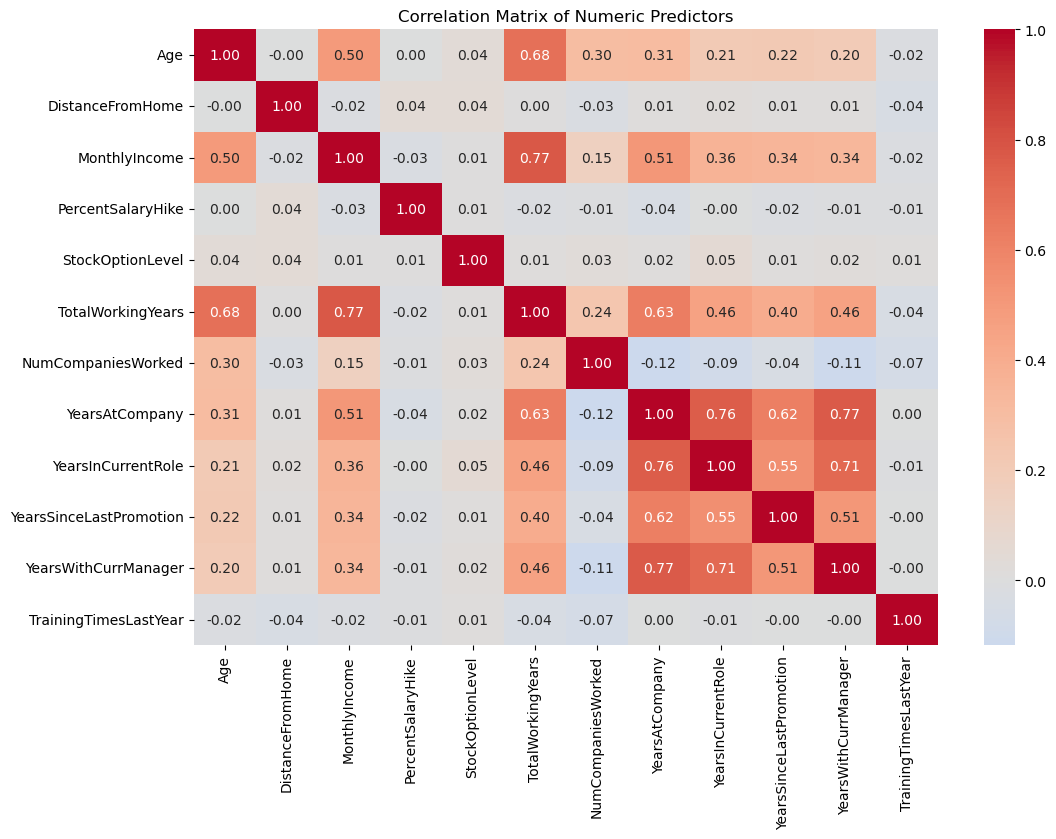

In [72]:
# Visualise correlations between numeric predictors
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Predictors")
plt.show()

### Correlation and multicollinearity assessment

The correlation matrix indicates that most numeric predictors have relatively low correlations with one another. However, several moderate to strong relationships are evident among variables relating to career experience, organisational tenure, and compensation.

The strongest correlations were observed between `MonthlyIncome` and `TotalWorkingYears` (**r = 0.77**), `YearsAtCompany` and `YearsWithCurrManager` (**r = 0.77**), `YearsAtCompany` and `YearsInCurrentRole` (**r = 0.76**), and `YearsInCurrentRole` and `YearsWithCurrManager` (**r = 0.71**). Moderate relationships were also observed between age, total working experience, organisational tenure, and years since promotion.

These relationships are conceptually plausible, as employees with greater career experience tend to be older and more highly paid, while longer-serving employees are also more likely to have spent longer in their current role and with their current manager.

The correlation matrix suggests potential multicollinearity among several career, tenure, and compensation variables. No variables will be removed based on pairwise correlations alone. The full predictor matrix will first be prepared, including dummy-coded categorical variables, before Variance Inflation Factor (VIF) is used to assess multicollinearity more comprehensively and inform final model specification.

## 5.3 Prepare the regression model

In [73]:
# Create a separate dataframe for modelling
model_data = employee_data[
    ["Attrition"] + predictor_columns
].copy()

In [74]:
# Convert Attrition to binary outcome
model_data["AttritionBinary"] = model_data["Attrition"].map({
    "No": 0,
    "Yes": 1
})

model_data[["Attrition", "AttritionBinary"]].head()

,Attrition,AttritionBinary
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [75]:
# Identify categorical predictor variables
categorical_predictors = model_data[predictor_columns].select_dtypes(
    include=["object", "category"]
).columns.tolist()

In [76]:
# Set preferred reference categories
model_data["MaritalStatus"] = pd.Categorical(
    model_data["MaritalStatus"],
    categories=["Married", "Divorced", "Single"]
)

model_data["EducationField"] = pd.Categorical(
    model_data["EducationField"],
    categories=[
        "Life Sciences",
        "Human Resources",
        "Marketing",
        "Medical",
        "Other",
        "Technical Degree"
    ]
)

model_data["Department"] = pd.Categorical(
    model_data["Department"],
    categories=[
        "Research & Development",
        "Human Resources",
        "Sales"
    ]
)

# Create predictor matrix after setting category order
X = model_data[predictor_columns].copy()

# Convert categorical predictors to dummy variables
X = pd.get_dummies(
    X,
    columns=categorical_predictors,
    drop_first=True,
    dtype=int
)

# Define the outcome variable
y = model_data["AttritionBinary"]

In [77]:
X.shape

(1470, 57)

In [78]:
X.head()

,Age,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,NumCompaniesWorked,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,...,RelationshipSatisfaction_Low,RelationshipSatisfaction_Medium,RelationshipSatisfaction_Very High,JobInvolvement_Low,JobInvolvement_Medium,JobInvolvement_Very High,WorkLifeBalance_Best,WorkLifeBalance_Better,WorkLifeBalance_Good,PerformanceRating_Outstanding
0,41,1,5993,11,0,8,8,6,4,0,...,1,0,0,0,0,0,0,0,0,0
1,49,8,5130,23,1,10,1,10,7,1,...,0,0,1,0,1,0,0,1,0,1
2,37,2,2090,15,0,7,6,0,0,0,...,0,1,0,0,1,0,0,1,0,0
3,33,3,2909,11,0,8,1,8,7,3,...,0,0,0,0,0,0,0,1,0,0
4,27,2,3468,12,1,6,9,2,2,2,...,0,0,1,0,0,0,0,1,0,0


In [79]:
X.columns.tolist()

['Age',
 'DistanceFromHome',
 'MonthlyIncome',
 'PercentSalaryHike',
 'StockOptionLevel',
 'TotalWorkingYears',
 'NumCompaniesWorked',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'TrainingTimesLastYear',
 'Gender_Male',
 'MaritalStatus_Divorced',
 'MaritalStatus_Single',
 'Education_College',
 'Education_Bachelor',
 'Education_Master',
 'Education_Doctor',
 'EducationField_Human Resources',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Department_Human Resources',
 'Department_Sales',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',
 'JobLevel_Junior Level',
 'JobLevel_Mid Level',
 'JobLevel_Senior Level',
 'JobLevel_Executive Level',
 'BusinessTravel_Travel_Rarely',
 'Busines

## 5.4 Assess multicollinearity and select the final specification

In [80]:
# Import the necessary packages
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add a constant to the full dummy-coded predictor matrix
X_vif = sm.add_constant(X)

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(X_vif.columns))
]

# Exclude the constant and display the highest VIF values first
vif_data[vif_data["Feature"] != "const"].sort_values(
    "VIF", ascending=False
).round(2)

,Feature,VIF
3,MonthlyIncome,20.61
26,Department_Sales,15.19
33,JobRole_Sales Executive,14.87
38,JobLevel_Executive Level,9.42
37,JobLevel_Senior Level,9.22
25,Department_Human Resources,8.08
27,JobRole_Human Resources,7.39
36,JobLevel_Mid Level,6.71
34,JobRole_Sales Representative,6.03
6,TotalWorkingYears,5.22


In [81]:
# Remove all Department dummy variables from the predictor matrix
department_columns = [
    col for col in X.columns
    if col.startswith("Department_")
]

X_reduced = X.drop(columns=department_columns)

# Recalculate VIF
X_vif = sm.add_constant(X_reduced)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(X_vif.columns))
]

vif_data[vif_data["Feature"] != "const"].sort_values(
    "VIF", ascending=False
).round(2)

,Feature,VIF
3,MonthlyIncome,20.59
36,JobLevel_Executive Level,9.40
35,JobLevel_Senior Level,9.21
34,JobLevel_Mid Level,6.71
6,TotalWorkingYears,5.21
53,WorkLifeBalance_Better,4.94
8,YearsAtCompany,4.82
30,JobRole_Research Scientist,4.47
33,JobLevel_Junior Level,4.32
54,WorkLifeBalance_Good,4.22


In [82]:
# Remove JobLevel dummy variables
X_reduced_2 = X_reduced.drop(
    columns=[
        "JobLevel_Executive Level",
        "JobLevel_Junior Level",
        "JobLevel_Mid Level",
        "JobLevel_Senior Level"
    ]
)

# Recalculate VIF
X_vif = sm.add_constant(X_reduced_2)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(X_vif.columns))
]

vif_data[vif_data["Feature"] != "const"].sort_values(
    "VIF", ascending=False
).round(2)

,Feature,VIF
3,MonthlyIncome,8.43
49,WorkLifeBalance_Better,4.93
6,TotalWorkingYears,4.85
8,YearsAtCompany,4.74
50,WorkLifeBalance_Good,4.22
30,JobRole_Research Scientist,3.37
27,JobRole_Manager,3.36
26,JobRole_Laboratory Technician,3.17
31,JobRole_Sales Executive,3.17
11,YearsWithCurrManager,2.86


In [83]:
# Create Model B predictor matrix
# Remove Department dummy variables and MonthlyIncome, but retain JobLevel

department_columns = [
    col for col in X.columns
    if col.startswith("Department_")
]

X_model_b = X.drop(
    columns=department_columns + ["MonthlyIncome"]
)

# Check VIF for Model B
X_vif_b = sm.add_constant(X_model_b)

vif_data_b = pd.DataFrame()
vif_data_b["Feature"] = X_vif_b.columns
vif_data_b["VIF"] = [
    variance_inflation_factor(X_vif_b.values, i)
    for i in range(len(X_vif_b.columns))
]

vif_data_b[vif_data_b["Feature"] != "const"].sort_values(
    "VIF", ascending=False
).round(2)

,Feature,VIF
5,TotalWorkingYears,5.14
52,WorkLifeBalance_Better,4.94
7,YearsAtCompany,4.82
34,JobLevel_Senior Level,4.76
35,JobLevel_Executive Level,4.33
29,JobRole_Research Scientist,4.27
53,WorkLifeBalance_Good,4.22
25,JobRole_Laboratory Technician,3.91
33,JobLevel_Mid Level,3.91
32,JobLevel_Junior Level,3.75


### Model specification decision

Before fitting the multivariate logistic regression model, the predictor set was reviewed to reduce redundancy and assess multicollinearity.

Variables with unclear business meaning, including `DailyRate`, `HourlyRate`, and `MonthlyRate`, were excluded from the modelling dataset. The remaining categorical variables were converted into dummy variables so that they could be included in the regression model, with one category retained as the reference group for each variable.

A correlation matrix was first used to examine pairwise relationships between numeric predictors. This identified several moderate to strong correlations among variables relating to career experience, organisational tenure, and compensation, including `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, and `MonthlyIncome`.

Variance Inflation Factor (VIF) was then used to assess multicollinearity across the full predictor set. The initial dummy-coded model showed particularly high VIF values for `MonthlyIncome`, several `JobLevel` categories, and overlapping `Department` and `JobRole` variables.

Because job role provides more detailed information than department, the `Department` variables were removed and VIF was recalculated. Two alternative model specifications were then considered: Model A retained `MonthlyIncome` and excluded `JobLevel`, while Model B retained `JobLevel` and excluded `MonthlyIncome`.

Model A reduced the VIF for `MonthlyIncome` from approximately **20.6 to 8.4**, but this remained notably higher than for most other predictors. In addition, `MonthlyIncome` was not statistically significant in the subsequent regression model. Model B avoided this remaining multicollinearity concern while retaining `JobLevel`, which provided substantively useful information about differences in attrition by seniority.

Model B was therefore selected as the preferred specification. The remaining predictors showed acceptable levels of multicollinearity and were retained for the final multivariate logistic regression analysis.

## 5.5 Fit the logistic regression model

In [84]:
# Add a constant to the predictor matrix
X_model = sm.add_constant(X_model_b)

# Fit the logistic regression model
logit_model = sm.Logit(y, X_model)

# Fit the model and display the results
logit_results = logit_model.fit()

logit_results.summary()

Optimization terminated successfully.
         Current function value: 0.271167
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        AttritionBinary   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1415
Method:                           MLE   Df Model:                           54
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                  0.3861
Time:                        13:06:33   Log-Likelihood:                -398.62
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 8.942e-74
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -2.1177      1.107     -1.913      0.056      -4.287       0.052
Age                                   -0.0307      0.014     -2.171      0.030      -0.058      -0.003
DistanceFromHome                       0.0556      0.011      4.887      0.000       0.033       0.078
PercentSalaryHike                     -0.0301      0.040     -0.747      0.455      -0.109       0.049
StockOptionLevel                      -0.1788      0.160     -1.118      0.264      -0.492       0.135
TotalWorkingYears                     -0.0653      0.030     -2.161      0.031      -0.125      -0.006
NumCompaniesWorked                     0.2086      0.041      5.151      0.000       0.129       0.288
YearsAtCompany                         0.0937      0.041      2.258      0.024       0.012       0.175
YearsInCurrentRole                    -0.1454      0.050     -2.928      0.003      -0.243      -0.048
YearsSinceLastPromotion                0.1777      0.044      3.995      0.000       0.091       0.265
YearsWithCurrManager                  -0.1392      0.050     -2.799      0.005      -0.237      -0.042
TrainingTimesLastYear                 -0.1793      0.075     -2.393      0.017      -0.326      -0.032
Gender_Male                            0.4278      0.194      2.209      0.027       0.048       0.807
MaritalStatus_Divorced                -0.4316      0.278     -1.551      0.121      -0.977       0.114
MaritalStatus_Single                   0.9281      0.262      3.546      0.000       0.415       1.441
Education_College                      0.1704      0.343      0.496      0.620      -0.502       0.843
Education_Bachelor                     0.1537      0.302      0.509      0.611      -0.438       0.745
Education_Master                       0.1261      0.329      0.383      0.701      -0.518       0.771
Education_Doctor                       0.2490      0.619      0.402      0.688      -0.964       1.462
EducationField_Human Resources         1.0886      0.794      1.372      0.170      -0.467       2.644
EducationField_Marketing               0.5412      0.335      1.614      0.107      -0.116       1.198
EducationField_Medical                -0.0013      0.228     -0.006      0.995      -0.449       0.446
EducationField_Other                   0.0986      0.437      0.226      0.822      -0.758       0.955
EducationField_Technical Degree        1.0023      0.322      3.114      0.002       0.371       1.633
JobRole_Human Resources                0.5134      0.742      0.692      0.489      -0.941       1.968
JobRole_Laboratory Technician          0.6070      0.585      1.037      0.300      -0.540       1.754
JobRole_Manager                       -0.8591      1.002     -0.857      0.391      -2.823       1.105
JobRole_Manufacturing Director         0.4506      0.549      0.820      0.412      -0.626       1.527
JobRole_Research Director             -2.0014   

## 5.6 Interpret odds ratios and significant associations

In [85]:
# Create odds-ratio table
odds_ratio_table = pd.DataFrame({
    "Coefficient": logit_results.params,
    "OddsRatio": np.exp(logit_results.params),
    "PValue": logit_results.pvalues,
    "CI_Lower": np.exp(logit_results.conf_int()[0]),
    "CI_Upper": np.exp(logit_results.conf_int()[1])
})

# Exclude the constant and sort by p-value
odds_ratio_table = (
    odds_ratio_table
    .drop(index="const")
    .sort_values("PValue")
    .round(3)
)

odds_ratio_table

,Coefficient,OddsRatio,PValue,CI_Lower,CI_Upper
OverTime_Yes,2.15e+00,8.60,0.00e+00,5.74,12.87
NumCompaniesWorked,2.09e-01,1.23,0.00e+00,1.14,1.33
DistanceFromHome,5.60e-02,1.06,0.00e+00,1.03,1.08
BusinessTravel_Travel_Frequently,2.12e+00,8.30,0.00e+00,3.48,19.78
JobInvolvement_Low,1.61e+00,5.02,0.00e+00,2.53,9.93
EnvironmentSatisfaction_Low,1.20e+00,3.31,0.00e+00,1.98,5.54
JobLevel_Junior Level,-1.80e+00,0.17,0.00e+00,0.07,0.40
YearsSinceLastPromotion,1.78e-01,1.19,0.00e+00,1.09,1.30
WorkLifeBalance_Better,-1.42e+00,0.24,0.00e+00,0.12,0.48
RelationshipSatisfaction_Low,9.80e-01,2.67,0.00e+00,1.59,4.48


In [86]:
# Keep statistically significant predictors, sort by odds ratio, and round for display
significant_odds_ratios = (
    odds_ratio_table[
        odds_ratio_table["PValue"] < 0.05
    ]
    .sort_values("OddsRatio", ascending=False)
    .round(3)
)

significant_odds_ratios

,Coefficient,OddsRatio,PValue,CI_Lower,CI_Upper
OverTime_Yes,2.15,8.60,0.00e+00,5.74,12.87
BusinessTravel_Travel_Frequently,2.12,8.30,0.00e+00,3.48,19.78
JobInvolvement_Low,1.61,5.02,0.00e+00,2.53,9.93
JobRole_Sales Executive,1.28,3.61,6.00e-03,1.44,9.02
EnvironmentSatisfaction_Low,1.20,3.31,0.00e+00,1.98,5.54
BusinessTravel_Travel_Rarely,1.19,3.28,4.00e-03,1.47,7.31
EducationField_Technical Degree,1.00,2.72,2.00e-03,1.45,5.12
RelationshipSatisfaction_Low,0.98,2.67,0.00e+00,1.59,4.48
MaritalStatus_Single,0.93,2.53,0.00e+00,1.51,4.23
JobSatisfaction_Low,0.68,1.97,7.00e-03,1.21,3.23


### Multivariate analysis: summary and comparison with bivariate findings

The multivariate results broadly reinforced several earlier bivariate patterns. Higher attrition odds remained significantly associated with **overtime, frequent business travel, longer distance from home, being single, low job involvement, and lower job, environment, or relationship satisfaction**. Greater total work experience, longer time in the current role, longer time with the current manager, and more training were associated with lower attrition odds.

Some relationships became more nuanced after adjustment. `JobLevel` remained informative, while several job-role effects weakened once seniority and other factors were considered simultaneously. Compensation measures such as `PercentSalaryHike` and `StockOptionLevel` were not significant in the final model, and the strong bivariate relationship between `MonthlyIncome` and attrition appears to be largely captured by job level and other career-related characteristics.

Overall, the results suggest that **working conditions, employee experience, seniority, and career history** provide stronger independent signals of attrition than compensation alone.

# Section 6: Predictive modelling

This section evaluates how effectively employee attrition can be predicted using the variables retained from the multivariate analysis.

The data are divided into training and test sets, with SMOTE applied to the training data to address class imbalance. Logistic regression and decision-tree classifiers are then evaluated using confusion matrices and classification metrics, with particular attention to performance for employees who left.

The purpose of this section is not only to assess predictive accuracy, but also to examine the trade-off between identifying more potential leavers and generating false positives, and to explore whether the decision tree reveals useful employee segments.

## 6.1 Prepare and balance the training data

In [87]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Apply SMOTE because the target variable is imbalanced
os = SMOTE(random_state=42)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_model_b,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Apply SMOTE to the training data only
os_data_X, os_data_y = os.fit_resample(X_train, y_train)

# Compare class distribution before and after SMOTE
print("Original training data:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(os_data_y.value_counts())

Original training data:
AttritionBinary
0    863
1    166
Name: count, dtype: int64

After SMOTE:
AttritionBinary
0    863
1    863
Name: count, dtype: int64


## 6.2 Logistic regression classification

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Fit logistic regression model using the SMOTE-balanced training data
logreg_model = LogisticRegression(max_iter=1000)

logreg_model.fit(os_data_X, os_data_y)

# Predict attrition for the test set
y_pred = logreg_model.predict(X_test)

pd.Series(y_pred).value_counts()

0    384
1     57
Name: count, dtype: int64

In [89]:
# Create the confusion matrix
confusion_matrix_result = confusion_matrix(y_test, y_pred)

# Display as a labelled table
confusion = pd.DataFrame(
    confusion_matrix_result,
    index=["Actual Stay", "Actual Leave"],
    columns=["Predicted Stay", "Predicted Leave"]
)

confusion

,Predicted Stay,Predicted Leave
Actual Stay,341,29
Actual Leave,43,28


In [90]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stay", "Leave"]
))

Accuracy: 0.837

Classification Report:
              precision    recall  f1-score   support

        Stay       0.89      0.92      0.90       370
       Leave       0.49      0.39      0.44        71

    accuracy                           0.84       441
   macro avg       0.69      0.66      0.67       441
weighted avg       0.82      0.84      0.83       441



### Interpretation

The logistic regression model achieved an overall accuracy of **83.7%**, but performance was much stronger for employees who stayed than for those who left.

For the `Leave` class, precision was **49%** and recall was **39%**, meaning that the model identified fewer than half of the actual leavers and also produced a substantial number of false positives. Overall, the model shows some ability to distinguish higher-risk employees, but its performance for predicting individual leavers remains limited.

In [91]:
# Fit logistic regression model using the SMOTE-balanced training data
logreg_model = LogisticRegression(max_iter=1000)

logreg_model.fit(os_data_X, os_data_y)

# Predict attrition for the test set
y_prob = logreg_model.predict_proba(X_test)[:, 1]

# Apply classification threshold
threshold = 0.5
thresholds = [0.50, 0.40, 0.30]

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision_Leave": tp / (tp + fp),
        "Recall_Leave": tp / (tp + fn),
        "Predicted_Leave": tp + fp,
        "True_Positive": tp,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Negative": tn
    })

threshold_results = pd.DataFrame(results).round(3)

threshold_results

,Threshold,Accuracy,Precision_Leave,Recall_Leave,Predicted_Leave,True_Positive,False_Positive,False_Negative,True_Negative
0,0.5,0.84,0.49,0.39,57,28,29,43,341
1,0.4,0.83,0.47,0.52,79,37,42,34,328
2,0.3,0.80,0.42,0.56,96,40,56,31,314


### Classification threshold comparison

Lowering the classification threshold increased the model's ability to identify employees who subsequently left, but also increased the number of false positives.

At the default threshold of **0.50**, recall for the `Leave` class was **39%**. Reducing the threshold to **0.40** increased recall to **52%**, while precision declined only slightly from **49% to 47%** and overall accuracy remained relatively stable.

A further reduction to **0.30** increased recall to **56%**, but precision fell to **42%** and the number of employees flagged as potential leavers increased substantially.

Reducing the threshold to 0.40 illustrates the trade-off between recall and precision, but does not in itself establish an appropriate operational threshold. Individual-level use of attrition predictions would require separate consideration of confidentiality, governance and the risk of labelling employees. For this case study, individual risk scores are therefore not recommended for management use.

## 6.3 Decision-tree classification and visualisation

In [92]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Fit a decision tree using the SMOTE-balanced training data
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(os_data_X, os_data_y)

# Predict attrition for the test set
y_pred_tree = tree_model.predict(X_test)

# Create confusion matrix
tree_confusion_matrix = confusion_matrix(y_test, y_pred_tree)

tree_confusion = pd.DataFrame(
    tree_confusion_matrix,
    index=["Actual Stay", "Actual Leave"],
    columns=["Predicted Stay", "Predicted Leave"]
)

tree_confusion

,Predicted Stay,Predicted Leave
Actual Stay,274,96
Actual Leave,37,34


In [93]:
# Print accuracy and classification report
print("Accuracy:", round(accuracy_score(y_test, y_pred_tree), 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["Stay", "Leave"]
))

Accuracy: 0.698

Classification Report:
              precision    recall  f1-score   support

        Stay       0.88      0.74      0.80       370
       Leave       0.26      0.48      0.34        71

    accuracy                           0.70       441
   macro avg       0.57      0.61      0.57       441
weighted avg       0.78      0.70      0.73       441



### Interpretation

The decision tree achieved lower overall accuracy than logistic regression, at **69.8%**, but identified a somewhat larger proportion of employees who left.

Recall for the `Leave` class was **48%**, compared with 39% for logistic regression, but precision fell to **26%**. This means the tree detected more actual leavers, but at the cost of substantially more false positives.

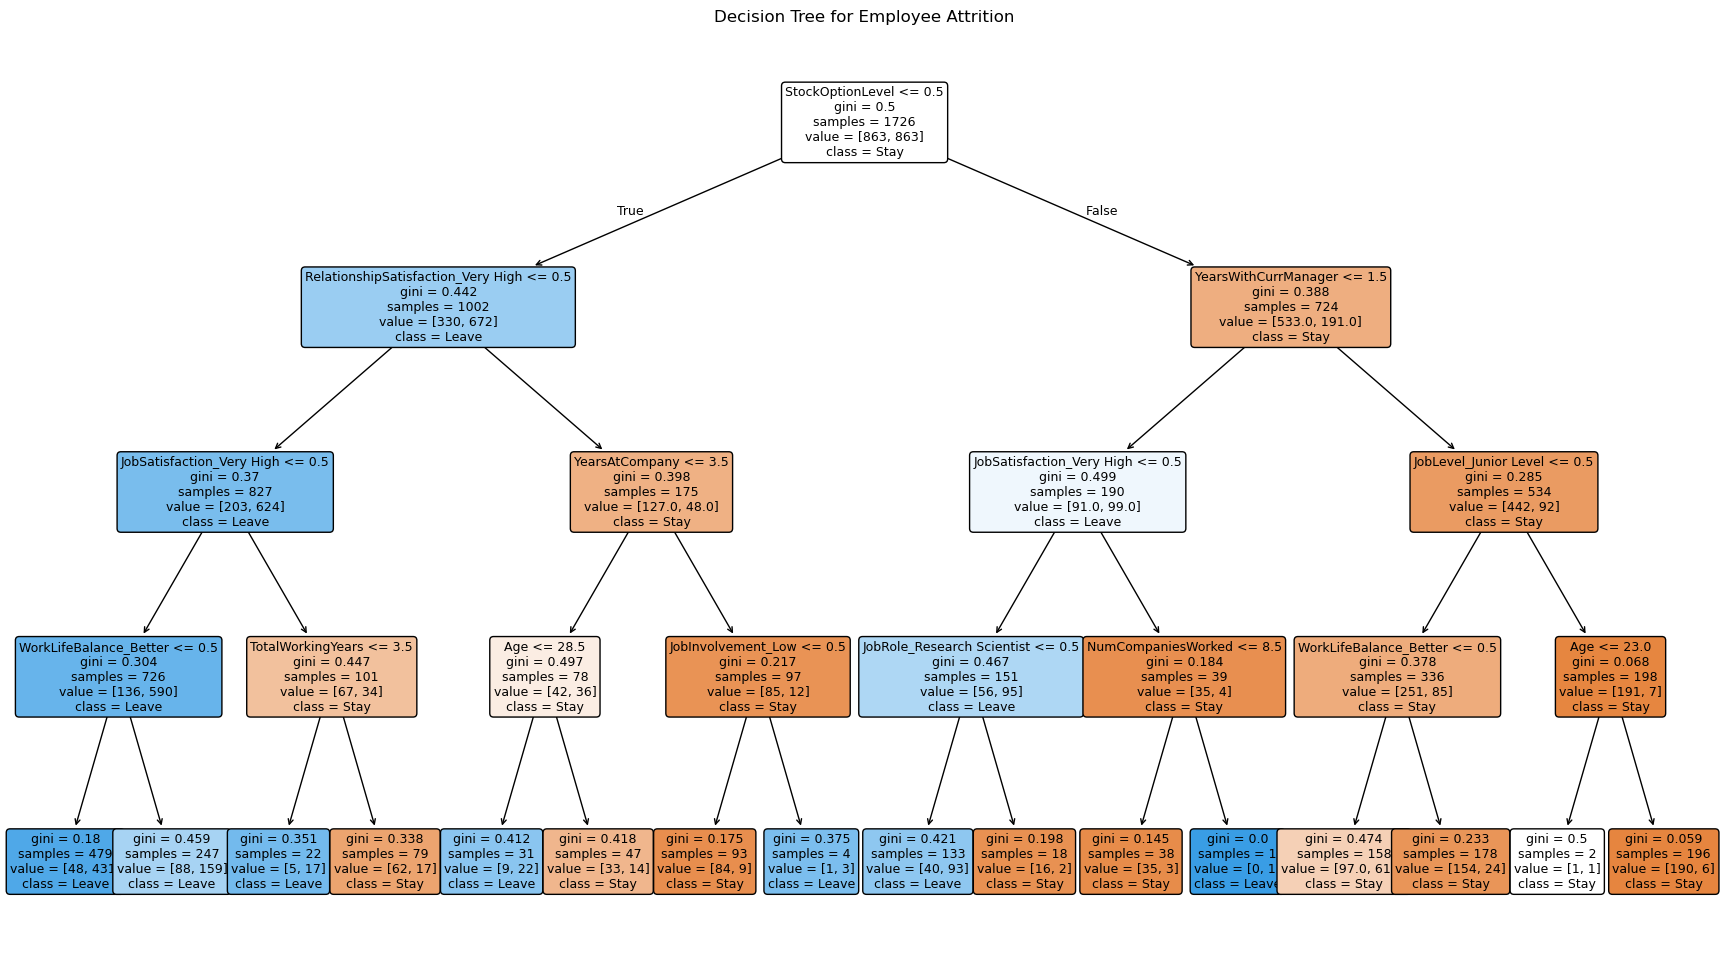

In [94]:
# Visualise the decision tree
plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=os_data_X.columns,
    class_names=["Stay", "Leave"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Employee Attrition")
plt.show()

## 6.4 Summary of predictive results

The predictive analysis used the final Model B predictor set. Because attrition represented only around **16%** of employees, SMOTE was applied to the training data to address class imbalance, while the test data retained the original class distribution.

The logistic regression model achieved an overall accuracy of **83.7%**, but performance for the `Leave` class was considerably weaker. Precision for leavers was **49%** and recall was **39%**, indicating that the model missed a majority of employees who actually left.

The decision tree achieved lower overall accuracy at **69.8%**, but recall for leavers increased to **48%**. This improvement came at the cost of substantially lower precision (**26%**), meaning that the tree identified more actual leavers but also generated many more false positives.

Although the decision tree did not outperform logistic regression overall, it provided additional segmentation insight by showing how factors such as stock-option level, satisfaction, work-life balance, tenure, job level, age and business travel interacted across different employee groups.

Overall, both models identify meaningful attrition patterns, but their ability to predict individual leavers reliably is limited. The results are therefore more useful for identifying areas for further investigation than for making individual-level predictions.

# Section 7: Practical implications

# Section 7: Conclusions, practical implications and limitations

## 7.1 Key conclusions

The analysis identified several clear patterns associated with attrition among Kansora Medical's high-performing employees.

The strongest adjusted associations were linked to **work demands and employee experience**. Overtime and frequent business travel were associated with substantially higher attrition odds, while better work-life balance was associated with lower attrition odds. Low job involvement and lower job, environment and relationship satisfaction were also associated with higher attrition.

Career and development factors showed additional relationships. Longer time in the current role, longer time with the current manager and more training were associated with lower attrition odds, although these effects were generally smaller.

By contrast, several compensation measures showed limited independent association with attrition after controlling for other workforce characteristics. In particular, `PercentSalaryHike` and `StockOptionLevel` were not statistically significant in the final model.

Overall, the results suggest that retention efforts should focus primarily on **work demands, employee experience and development**, rather than assuming that compensation alone is the main driver of attrition.


## 7.2 Practical implications

The findings provide a basis for prioritising several areas for management attention.

- **Work demands and balance:** Persistent overtime should be treated as a potential retention risk. Business leaders and HR should also review whether frequent or concentrated business travel can be reduced or better managed, and investigate workload or work-design issues where work-life balance is weak.
- **Employee experience:** Survey results relating to job involvement and satisfaction should be used to identify local issues and support targeted action planning. Leaders should focus on understanding the underlying causes of weaker scores rather than applying generic engagement interventions.
- **Career and development:** Employees may benefit from stronger support during role and manager transitions, together with continued access to relevant training and development opportunities.
- **Compensation:** Salary increases and stock options should not be treated as the primary retention lever in isolation, as neither showed a clear independent association with attrition in the final model.

These findings should be used as a framework rather than as a single organisation-wide prescription. Business leaders should work with their HR Business Partners to identify which issues are most relevant to their own teams and develop appropriate local actions.


## 7.3 Predictive modelling and appropriate use

The predictive models identified some attrition signal, but their ability to identify individual leavers reliably was limited.

At the default classification threshold, logistic regression achieved an overall accuracy of approximately **84%**, but identified only **39% of actual leavers**. This overall accuracy also needs to be interpreted against the class distribution: because approximately 84% of employees stayed, a model predicting that every employee would stay would achieve a similar level of accuracy.

Reducing the classification threshold improved recall, illustrating the trade-off between identifying more potential leavers and generating more false positives. However, selecting an operational threshold is not simply a statistical decision.

Individual attrition-risk scores also raise important **confidentiality, governance and employee-labelling concerns**, particularly where survey-related variables contribute to the prediction. For this case study, individual-level attrition scores are therefore not recommended for management use. The predictive analysis is more useful for demonstrating the limits and governance considerations of individual attrition prediction than for identifying named employees for intervention.


## 7.4 Limitations

Several limitations should be considered when interpreting the findings.

- The analysis identifies **associations rather than causal relationships**. A statistically significant predictor should not be assumed to cause attrition.
- Some survey-related variables, including measures of satisfaction and involvement, are not defined in sufficient detail to identify the specific underlying issues driving employee responses.
- Several workforce characteristics are related to one another, requiring model specification decisions to manage multicollinearity.
- Some categorical groups contain relatively small numbers of employees, so individual estimates should be interpreted cautiously.
- Predictive performance for employees who left remained limited, and individual risk scores should not be treated as definitive predictions.
- The results reflect the workforce and observation period represented in this analysis and should be reassessed as new attrition and employee-experience data become available.


## 7.5 Overall conclusion

The analysis suggests that Kansora Medical's strongest retention priorities lie in **managing work demands, improving employee experience and supporting career development**.

The findings provide a stronger evidence base for deciding where HR and business leaders should focus their attention, while also showing that predictive modelling should not automatically be translated into individual-level management action.

The most appropriate next step is therefore to use these findings to guide local diagnosis and targeted retention actions, then review whether both workforce indicators and attrition patterns improve over time.